# Chapitre 7 — POMDP & Non-Markovien : Détection Adaptative des Intrusions
## Modélisation Stochastique de la Sécurité des Réseaux Informatiques

**Dataset :** UNSW-NB15 (training-set : 175 341 enregistrements, testing-set : 82 332)  
**Modèles :** POMDP · Self-Adaptive POMDP · Self-Adaptive Deep POMDP · POMDP non-Markovien · Deep POMDP non-Markovien  
**Cas traités :** Variable aléatoire scalaire ET vecteur aléatoire  
**Encadrant :** Dr. Abdellatif El Afia  
**Réalisé par :** Fidaa Ariyan

---

### Contexte et Lien avec les Chapitres Précédents

Le **Chapitre 5 (MDP)** supposait que l'agent connaissait l'état exact du réseau à chaque instant.  
Le **Chapitre 6 (RL)** levait l'hypothèse de connaissance de P et R, mais gardait l'état pleinement observable.  
Le **Chapitre 7 (POMDP)** va plus loin : **l'état réel est caché**. L'agent ne perçoit qu'une **observation partielle** (flux réseau, métriques agrégées). Il doit maintenir une **croyance (belief state)** sur l'état réel et prendre des décisions optimales malgré cette incertitude.

| Modèle | État observable ? | Transitions Markoviennes ? | Adaptation |
|--------|-----------------|---------------------------|------------|
| MDP (Ch.5) | ✅ Oui | ✅ Oui | ❌ Fixe |
| RL (Ch.6) | ✅ Oui | ✅ Oui (apprise) | Partielle |
| POMDP | ❌ Non | ✅ Oui | Belief update |
| Self-Adaptive POMDP | ❌ Non | ✅ Oui | ✅ Auto-adaptation |
| Self-Adaptive Deep POMDP | ❌ Non | ✅ Oui | ✅ Réseau de neurones |
| Non-Markovien POMDP | ❌ Non | ❌ Non | Mémoire d'historique |
| Non-Markovien Deep POMDP | ❌ Non | ❌ Non | ✅ LSTM/RNN |

**Référence principale :**  
- Kaelbling, L.P., Littman, M.L., Cassandra, A.R. (1998). *Planning and acting in partially observable stochastic domains*. Artificial Intelligence, 101(1-2), 99-134.  
- Pineau, J., Gordon, G., Thrun, S. (2003). *Point-based value iteration: An anytime algorithm for POMDPs*. IJCAI.  
- Hausknecht, M., Stone, P. (2015). *Deep Recurrent Q-Networks for Partially Observable MDPs*. AAAI.


## 1. Imports et Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report
from scipy.special import softmax
from collections import defaultdict, deque
import itertools

np.random.seed(42)
print("✅ Imports OK")

✅ Imports OK


## 2. Chargement du Dataset UNSW-NB15

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# ADAPTEZ CES CHEMINS à votre environnement
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_PATH = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv'
TEST_PATH  = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CSV Files\Training and Testing Sets\UNSW_NB15_testing-set.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

# Label binaire : 1 = attaque, 0 = normal
TARGET = 'label'
if TARGET not in df_train.columns:
    TARGET = df_train.columns[-1]

print(f"Train : {df_train.shape} | Test : {df_test.shape}")
print(f"Colonne cible : '{TARGET}'")
print(df_train[TARGET].value_counts())

Train : (175341, 45) | Test : (82332, 45)
Colonne cible : 'label'
label
1    119341
0     56000
Name: count, dtype: int64


## 3. Construction de l'Espace d'États et des Observations

### Architecture POMDP

Un POMDP est défini par le tuple **(S, A, T, R, Ω, O, γ)** :

- **S** = {Normal, Menace_Faible, Menace_Moyenne, Menace_Élevée} — états **cachés**
- **A** = {Surveiller, Alerter, Bloquer} — actions de l'agent
- **T(s'|s,a)** — matrice de transition (même que Ch.5)
- **R(s,a)** — récompense (même que Ch.5)
- **Ω** = {Obs_Normal, Obs_Suspect, Obs_Critique} — **observations** (ce que l'agent perçoit)
- **O(o|s',a)** — matrice d'émission : P(observation | état réel, action)
- **γ** = 0.95 — facteur d'actualisation

### Variable Aléatoire vs Vecteur Aléatoire

- **CAS 1 (Scalaire)** : l'observation est un entier o ∈ {0,1,2} (catégorie discrète)
- **CAS 2 (Vecteur)** : l'observation est un vecteur continu φ(o) ∈ ℝ^d (features réseau)

In [3]:
# ─── Features numériques disponibles ─────────────────────────────────────────
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
exclude = [TARGET, 'id', 'attack_cat'] if 'attack_cat' in df_train.columns else [TARGET]
available_features = [c for c in numeric_cols if c not in exclude]
available_features = available_features[:15]  # top 15 features

X_train = df_train[available_features].fillna(0).replace([np.inf, -np.inf], 0)
X_test  = df_test[available_features].fillna(0).replace([np.inf, -np.inf], 0)
y_train = df_train[TARGET].values.astype(int)
y_test  = df_test[TARGET].values.astype(int)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ─── K-Means 4 états cachés (S) ─────────────────────────────────────────────
N_STATES   = 4    # états cachés
N_ACTIONS  = 3    # Surveiller, Alerter, Bloquer
N_OBS      = 3    # observations : Obs_Normal, Obs_Suspect, Obs_Critique

kmeans = KMeans(n_clusters=N_STATES, random_state=42, n_init=10)
kmeans.fit(X_train_sc)

train_states = kmeans.predict(X_train_sc)
test_states  = kmeans.predict(X_test_sc)

# Réordonner états par taux d'attaque croissant
state_attack_rate = [y_train[train_states == s].mean() for s in range(N_STATES)]
order = np.argsort(state_attack_rate)
state_map = {old: new for new, old in enumerate(order)}
train_states = np.array([state_map[s] for s in train_states])
test_states  = np.array([state_map[s] for s in test_states])

state_names = ['Normal', 'Menace Faible', 'Menace Moyenne', 'Menace Élevée']
obs_names   = ['Obs_Normal', 'Obs_Suspect', 'Obs_Critique']
action_names = ['Surveiller', 'Alerter', 'Bloquer']

print("✅ États cachés construits")
for s in range(N_STATES):
    mask = train_states == s
    print(f"  État {s} ({state_names[s]:15s}) : {mask.sum():6d} enreg. | "
          f"taux attaque = {y_train[mask].mean()*100:.1f}%")

✅ États cachés construits
  État 0 (Normal         ) :  60517 enreg. | taux attaque = 26.0%
  État 1 (Menace Faible  ) : 114687 enreg. | taux attaque = 90.2%
  État 2 (Menace Moyenne ) :     89 enreg. | taux attaque = 100.0%
  État 3 (Menace Élevée  ) :     48 enreg. | taux attaque = 100.0%


In [4]:
# ─── Matrice de Transition T(s'|s,a) ─────────────────────────────────────────
# Estimée empiriquement (identique Ch.5), puis perturbée selon l'action
def build_transition_matrix(states_seq, n_states):
    """Matrice de transition empirique."""
    C = np.zeros((n_states, n_states))
    for t in range(len(states_seq)-1):
        C[states_seq[t], states_seq[t+1]] += 1
    # Normaliser
    row_sums = C.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return C / row_sums

T_base = build_transition_matrix(train_states, N_STATES)

# T[a] = matrice de transition pour l'action a
# Action 0 (Surveiller) : transitions naturelles
# Action 1 (Alerter)    : légère réduction des transitions vers états élevés
# Action 2 (Bloquer)    : forte réduction des transitions vers états élevés
T = np.zeros((N_ACTIONS, N_STATES, N_STATES))
T[0] = T_base.copy()

# Action Alerter : augmente prob de rester en état sûr
T_alert = T_base.copy()
T_alert[:, 2:] *= 0.7
T_alert[:, :2] *= 1.3
T_alert = T_alert / T_alert.sum(axis=1, keepdims=True)
T[1] = T_alert

# Action Bloquer : forte réduction vers états dangereux
T_block = T_base.copy()
T_block[:, 2:] *= 0.3
T_block[:, :2] *= 1.7
T_block = T_block / T_block.sum(axis=1, keepdims=True)
T[2] = T_block

# ─── Matrice de Récompense R(s,a) ────────────────────────────────────────────
R = np.array([
#   Surveiller  Alerter  Bloquer
    [  10,        5,      -10],   # État 0 : Normal
    [   0,       15,       -5],   # État 1 : Menace Faible
    [ -10,       10,       20],   # État 2 : Menace Moyenne
    [ -20,        0,       30],   # État 3 : Menace Élevée
])

# ─── Matrice d'Émission O(o|s,a) ─────────────────────────────────────────────
# P(observation | état caché) — modélise la confusion du capteur
#                   Obs_Normal  Obs_Suspect  Obs_Critique
O_base = np.array([
    [0.80,         0.15,        0.05],   # État 0 : Normal
    [0.40,         0.45,        0.15],   # État 1 : Menace Faible
    [0.10,         0.40,        0.50],   # État 2 : Menace Moyenne
    [0.05,         0.15,        0.80],   # État 3 : Menace Élevée
])

# O[a] = même matrice d'émission (indépendante de l'action ici)
O = np.stack([O_base] * N_ACTIONS, axis=0)  # (N_ACTIONS, N_STATES, N_OBS)

print("✅ Matrices POMDP construites")
print(f"T : {T.shape}  |  R : {R.shape}  |  O : {O.shape}")
print("\nMatrice d'émission O(o|s) :")
df_O = pd.DataFrame(O_base, index=state_names, columns=obs_names)
print(df_O.round(2))

✅ Matrices POMDP construites
T : (3, 4, 4)  |  R : (4, 3)  |  O : (3, 4, 3)

Matrice d'émission O(o|s) :
                Obs_Normal  Obs_Suspect  Obs_Critique
Normal                0.80         0.15          0.05
Menace Faible         0.40         0.45          0.15
Menace Moyenne        0.10         0.40          0.50
Menace Élevée         0.05         0.15          0.80


## 4. Belief State — Mise à Jour Bayésienne

Le **belief state** b(s) est la distribution de probabilité sur les états cachés, compte tenu de l'historique des observations.

### Mise à jour de la croyance (Bayes filter)

$$b'(s') = \eta \cdot O(o | s', a) \cdot \sum_{s} T(s'|s,a) \cdot b(s)$$

où η est un facteur de normalisation. Cette équation est le **filtre de Bayes discret**.

### Interprétation en cybersécurité

- b(0) = probabilité que le réseau soit **Normal** sachant les observations passées
- b(3) = probabilité d'être sous **Menace Élevée** — déclenche le blocage

#### CAS 1 — Variable Aléatoire Scalaire

L'observation o ∈ {0,1,2} est un entier (catégorie discrète). La croyance b ∈ ℝ⁴ est un vecteur de 4 probabilités.

#### CAS 2 — Vecteur Aléatoire

L'observation est un vecteur φ(x) ∈ ℝ^d. La vraisemblance est calculée via une densité gaussienne : P(φ|s) = N(φ; μₛ, Σₛ).

In [5]:
# ─── CAS 1 : Mise à jour belief — Variable aléatoire scalaire ─────────────────
def belief_update_scalar(b, a, o, T, O):
    """
    Mise à jour Bayésienne du belief state (cas scalaire).
    
    Paramètres:
    -----------
    b : array (N_STATES,) — croyance courante
    a : int — action prise
    o : int — observation reçue
    T : array (N_ACTIONS, N_STATES, N_STATES)
    O : array (N_ACTIONS, N_STATES, N_OBS)
    
    Retourne:
    ---------
    b_new : array (N_STATES,) — croyance mise à jour
    """
    n_states = len(b)
    b_pred = T[a].T @ b                # Prédiction : b_pred[s'] = sum_s T[a][s,s'] b[s]
    b_new  = O[a, :, o] * b_pred      # Correction Bayésienne
    norm   = b_new.sum()
    if norm < 1e-10:
        return np.ones(n_states) / n_states  # Réinitialisation si vraisemblance nulle
    return b_new / norm

# ─── CAS 2 : Mise à jour belief — Vecteur aléatoire ──────────────────────────
def multivariate_gaussian_likelihood(x, mu, sigma_diag):
    """Vraisemblance gaussienne multivariée (diagonale)."""
    d = len(x)
    diff = x - mu
    log_lik = -0.5 * np.sum((diff**2) / (sigma_diag + 1e-8))
    log_lik -= 0.5 * np.sum(np.log(2 * np.pi * sigma_diag + 1e-8))
    return np.exp(np.clip(log_lik, -500, 0))

def belief_update_vector(b, a, obs_vec, T, mu_states, sigma_states):
    """
    Mise à jour Bayésienne du belief state (cas vecteur continu).
    La vraisemblance P(obs|s) est modélisée par une gaussienne multivariée.
    """
    b_pred = T[a].T @ b
    likelihoods = np.array([
        multivariate_gaussian_likelihood(obs_vec, mu_states[s], sigma_states[s])
        for s in range(len(b))
    ])
    b_new = likelihoods * b_pred
    norm  = b_new.sum()
    if norm < 1e-10:
        return np.ones(len(b)) / len(b)
    return b_new / norm

# ─── Calcul des paramètres gaussiens par état (pour CAS 2) ───────────────────
mu_states    = np.array([X_train_sc[train_states == s].mean(axis=0) 
                         for s in range(N_STATES)])
sigma_states = np.array([X_train_sc[train_states == s].var(axis=0) + 1e-4
                         for s in range(N_STATES)])

# ─── Test de cohérence ────────────────────────────────────────────────────────
b0 = np.array([0.7, 0.2, 0.07, 0.03])  # Croyance initiale
b1 = belief_update_scalar(b0, a=0, o=1, T=T, O=O)
print("✅ Belief update (scalaire)")
print(f"  b0 = {b0}")
print(f"  b1 (après obs=Suspect, action=Surveiller) = {b1.round(4)}")

obs_sample = X_test_sc[0]
b1_vec = belief_update_vector(b0, 0, obs_sample, T, mu_states, sigma_states)
print(f"\n✅ Belief update (vectoriel)")
print(f"  b1 (vecteur) = {b1_vec.round(4)}")

✅ Belief update (scalaire)
  b0 = [0.7  0.2  0.07 0.03]
  b1 (après obs=Suspect, action=Surveiller) = [3.002e-01 6.988e-01 4.000e-04 5.000e-04]

✅ Belief update (vectoriel)
  b1 (vecteur) = [0. 1. 0. 0.]


## 5. POMDP Standard — Point-Based Value Iteration (PBVI)

### Principe : α-vecteurs

La fonction de valeur V(b) dans un POMDP est **linéaire par morceaux et convexe** dans l'espace des croyances. Elle est représentée par un ensemble de **vecteurs α** :

$$V(b) = \max_{\alpha \in \Gamma} \alpha^\top b$$

Chaque α-vecteur correspond à une politique sur un horizon fini.

### Algorithme PBVI

1. Initialiser un ensemble de points de croyance B = {b₀, b₁, ...}
2. Pour chaque b ∈ B, calculer le meilleur α-vecteur par **backup**
3. Éliminer les α-vecteurs dominés
4. Répéter jusqu'à convergence

In [6]:
# ─── PBVI — Point-Based Value Iteration ──────────────────────────────────────
class POMDPSolver:
    """
    Solveur POMDP par Point-Based Value Iteration (PBVI).
    
    Kaelbling et al. (1998) & Pineau et al. (2003).
    """
    def __init__(self, T, R, O, gamma=0.95, n_states=4, n_actions=3, n_obs=3):
        self.T        = T
        self.R        = R
        self.O        = O
        self.gamma    = gamma
        self.n_states = n_states
        self.n_actions= n_actions
        self.n_obs    = n_obs
        # Alpha-vecteurs : initialisés à la récompense max par action
        self.alpha_vectors = []
        self.alpha_actions = []
        for a in range(n_actions):
            self.alpha_vectors.append(R[:, a].copy())
            self.alpha_actions.append(a)

    def _backup(self, b):
        """
        Calcule le meilleur α-vecteur pour le point de croyance b.
        Implémente le backup PBVI.
        """
        best_alpha = None
        best_val   = -np.inf
        best_a     = 0

        for a in range(self.n_actions):
            # Récompense immédiate
            r_vec = self.R[:, a]

            # Pour chaque observation o, trouver le meilleur alpha-vecteur existant
            alpha_ao = np.zeros(self.n_states)
            for o in range(self.n_obs):
                # Vecteur intermédiaire : projection de chaque alpha via T et O
                proj_alphas = []
                for alpha_j in self.alpha_vectors:
                    v = np.array([
                        np.sum(self.T[a, s, :] * self.O[a, :, o] * alpha_j)
                        for s in range(self.n_states)
                    ])
                    proj_alphas.append(v)
                proj_alphas = np.array(proj_alphas)  # (n_alpha, n_states)

                # Choisir l'alpha projeté qui maximise b · alpha
                vals = proj_alphas @ b
                best_idx = np.argmax(vals)
                alpha_ao += proj_alphas[best_idx]

            new_alpha = r_vec + self.gamma * alpha_ao
            val = new_alpha @ b
            if val > best_val:
                best_val   = val
                best_alpha = new_alpha
                best_a     = a

        return best_alpha, best_a

    def solve(self, belief_points, n_iterations=20):
        """
        Résoudre le POMDP par PBVI sur un ensemble de points de croyance.
        """
        value_history = []

        for iteration in range(n_iterations):
            new_alphas = []
            new_actions= []

            for b in belief_points:
                alpha, a = self._backup(b)
                new_alphas.append(alpha)
                new_actions.append(a)

            # Mise à jour : garder uniquement les alpha non dominés
            self.alpha_vectors = new_alphas
            self.alpha_actions = new_actions

            # Valeur moyenne sur les points de croyance
            vals = [max(alpha @ b for alpha in self.alpha_vectors) 
                    for b in belief_points]
            value_history.append(np.mean(vals))

            if iteration % 5 == 0:
                print(f"  Itération {iteration:3d} | V(b) moyen = {np.mean(vals):.4f}")

        return value_history

    def get_action(self, b):
        """Retourne l'action optimale pour la croyance b."""
        if not self.alpha_vectors:
            return np.argmax(b)  # fallback
        vals   = [alpha @ b for alpha in self.alpha_vectors]
        best_i = np.argmax(vals)
        return self.alpha_actions[best_i]

    def get_value(self, b):
        """Retourne la valeur estimée pour la croyance b."""
        if not self.alpha_vectors:
            return 0.0
        return max(alpha @ b for alpha in self.alpha_vectors)


# ─── Génération des points de croyance (exploration) ─────────────────────────
def generate_belief_points(n_states, n_points=50):
    """Génère des points de croyance par simulation aléatoire."""
    points = []
    # Coins du simplexe
    for s in range(n_states):
        b = np.zeros(n_states)
        b[s] = 1.0
        points.append(b)
    # Points aléatoires sur le simplexe
    for _ in range(n_points - n_states):
        b = np.random.dirichlet(np.ones(n_states))
        points.append(b)
    return points

belief_points = generate_belief_points(N_STATES, n_points=30)

print("🔧 Résolution POMDP par PBVI...")
pomdp_solver = POMDPSolver(T, R, O, gamma=0.95)
value_history_pbvi = pomdp_solver.solve(belief_points, n_iterations=20)
print("✅ PBVI terminé")

🔧 Résolution POMDP par PBVI...
  Itération   0 | V(b) moyen = 24.0325
  Itération   5 | V(b) moyen = 71.6653
  Itération  10 | V(b) moyen = 108.1674
  Itération  15 | V(b) moyen = 136.3901
✅ PBVI terminé


## 6. Self-Adaptive POMDP

### Principe

Le **Self-Adaptive POMDP** étend le POMDP standard en permettant à l'agent d'**adapter automatiquement** ses paramètres (matrices T, O) lorsqu'il détecte un changement de comportement du réseau.

$$\Delta = \| b_{t} - b_{t-1} \|_2 > \theta_{\text{adapt}}$$

Si la divergence de la croyance dépasse un seuil θ, l'agent déclenche une **ré-estimation** des matrices T et O à partir des transitions récentes.

**Application cybersécurité :** Détection de zero-day attacks — le comportement du réseau change soudainement, et l'agent doit recalibrer son modèle.

#### CAS 1 (Scalaire) : adaptation sur belief discret  
#### CAS 2 (Vecteur) : adaptation sur embedding vectoriel

In [7]:
class SelfAdaptivePOMDP:
    """
    POMDP Self-Adaptatif : réestimation en-ligne de T et O.
    
    Algorithme :
    1. Maintenir un buffer circulaire de (s_est, a, o, s_next_est)
    2. Calculer la divergence du belief à chaque pas
    3. Si divergence > seuil : réestimer T et O par MLE
    4. Résoudre à nouveau le POMDP avec les nouveaux paramètres
    """
    def __init__(self, T_init, R, O_init, gamma=0.95,
                 adapt_threshold=0.3, buffer_size=500, adapt_interval=100):
        self.T      = T_init.copy()
        self.R      = R.copy()
        self.O      = O_init.copy()
        self.gamma  = gamma
        self.n_states  = R.shape[0]
        self.n_actions = T_init.shape[0]
        self.n_obs     = O_init.shape[2]

        self.adapt_threshold = adapt_threshold
        self.buffer_size     = buffer_size
        self.adapt_interval  = adapt_interval

        # Solver POMDP interne
        self.solver = POMDPSolver(self.T, self.R, self.O, gamma)
        self.belief_points = generate_belief_points(self.n_states, 20)
        self.solver.solve(self.belief_points, n_iterations=10)

        # Buffer de transitions observées
        self.transition_buffer = deque(maxlen=buffer_size)  # (a, o_prev, o_curr)
        self.n_adaptations = 0
        self.adaptation_log = []

    def _reestimate_O(self):
        """Réestimation de O par MLE à partir du buffer."""
        counts = np.zeros((self.n_actions, self.n_states, self.n_obs)) + 0.1  # Laplace smoothing
        for (a, b_prev, o) in self.transition_buffer:
            s_est = np.argmax(b_prev)
            if o < self.n_obs:
                counts[a, s_est, o] += 1
        counts /= counts.sum(axis=2, keepdims=True)
        # Interpolation avec O original (stabilité)
        self.O = 0.7 * counts + 0.3 * self.O

    def _reestimate_T(self):
        """Réestimation de T par MLE à partir du buffer."""
        counts = np.zeros((self.n_actions, self.n_states, self.n_states)) + 0.1
        buf_list = list(self.transition_buffer)
        for i in range(len(buf_list) - 1):
            a, b_prev, o = buf_list[i]
            _, b_curr, _ = buf_list[i+1]
            s_prev = np.argmax(b_prev)
            s_curr = np.argmax(b_curr)
            counts[a, s_prev, s_curr] += 1
        counts /= counts.sum(axis=2, keepdims=True)
        self.T = 0.7 * counts + 0.3 * self.T

    def step(self, b, a, o, t):
        """
        Un pas de décision + mise à jour belief + adaptation conditionnelle.
        """
        # Ajouter au buffer
        self.transition_buffer.append((a, b.copy(), o))

        # Mise à jour du belief
        b_new = belief_update_scalar(b, a, o, self.T, self.O)

        # Calculer la divergence (L2 entre beliefs)
        divergence = np.linalg.norm(b_new - b)

        adapted = False
        if (t % self.adapt_interval == 0 and t > 0
                and len(self.transition_buffer) >= 50):
            if divergence > self.adapt_threshold:
                self._reestimate_O()
                self._reestimate_T()
                # Résoudre à nouveau
                self.solver = POMDPSolver(self.T, self.R, self.O, self.gamma)
                self.solver.solve(self.belief_points, n_iterations=5)
                self.n_adaptations += 1
                adapted = True
                self.adaptation_log.append((t, divergence))

        action_next = self.solver.get_action(b_new)
        return b_new, action_next, divergence, adapted


# ─── Simulation CAS 1 (Scalaire) ─────────────────────────────────────────────
def simulate_obs_from_state(s, O, n_obs):
    """Génère une observation aléatoire depuis l'état s."""
    return np.random.choice(n_obs, p=O[0, s, :])

print("🔧 Simulation Self-Adaptive POMDP (CAS SCALAIRE)...")
sa_pomdp = SelfAdaptivePOMDP(T, R, O, adapt_threshold=0.25, buffer_size=300, adapt_interval=50)

n_sim = 500
b = np.array([0.7, 0.2, 0.07, 0.03])

results_sa = {
    'beliefs': [b.copy()], 'actions': [], 'rewards': [],
    'divergences': [], 'adaptations': [], 'obs_seq': []
}

current_state = test_states[0]
for t in range(n_sim):
    a = sa_pomdp.solver.get_action(b)
    # Simuler observation depuis état réel
    o = simulate_obs_from_state(current_state, O, N_OBS)
    r = R[current_state, a]

    b_new, a_next, div, adapted = sa_pomdp.step(b, a, o, t)

    results_sa['beliefs'].append(b_new.copy())
    results_sa['actions'].append(a)
    results_sa['rewards'].append(r)
    results_sa['divergences'].append(div)
    results_sa['adaptations'].append(adapted)
    results_sa['obs_seq'].append(o)

    b = b_new
    # Transition d'état
    current_state = np.random.choice(N_STATES, p=T[a, current_state, :])

print(f"✅ Simulation terminée | Adaptations déclenchées : {sa_pomdp.n_adaptations}")
print(f"   Récompense cumulée : {sum(results_sa['rewards']):.1f}")

🔧 Simulation Self-Adaptive POMDP (CAS SCALAIRE)...
  Itération   0 | V(b) moyen = 25.2008
  Itération   5 | V(b) moyen = 73.0800
  Itération   0 | V(b) moyen = 22.9058
✅ Simulation terminée | Adaptations déclenchées : 1
   Récompense cumulée : 5985.0


## 7. Self-Adaptive Deep POMDP

### Principe

Le **Self-Adaptive Deep POMDP** remplace la représentation tabulaire de la fonction de valeur par un **réseau de neurones dense** (MLP) :

$$V_{\theta}(b) \approx V^*(b)$$

Le réseau prend en entrée le vecteur de croyance b ∈ ℝ⁴ et prédit la valeur V(b). Il est entraîné par **descente de gradient** sur les erreurs de Bellman :

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(V_{\theta}(b) - \left[R(b,a) + \gamma V_{\theta}(b')\right]\right)^2\right]$$

L'adaptation self-adaptive met à jour le réseau lorsqu'une dérive de la distribution des observations est détectée.

#### CAS 2 — Vecteur Aléatoire

Le réseau reçoit en entrée **le vecteur de croyance concatené avec l'observation vectorielle** : [b; φ(x)] ∈ ℝ^(4+d).

In [8]:
# ─── MLP simple (NumPy uniquement, sans frameworks externes) ──────────────────
class SimpleMLPValueNet:
    """
    Réseau de neurones dense (MLP) pour approximer V(b) dans un Deep POMDP.
    Architecture : input → hidden1 → hidden2 → output
    Activation : ReLU
    """
    def __init__(self, input_dim, hidden_dims=(32, 16), lr=0.001):
        self.lr = lr
        dims = [input_dim] + list(hidden_dims) + [1]
        self.W = []
        self.b_bias = []
        for i in range(len(dims)-1):
            # He initialization
            W = np.random.randn(dims[i], dims[i+1]) * np.sqrt(2.0 / dims[i])
            b = np.zeros(dims[i+1])
            self.W.append(W)
            self.b_bias.append(b)
        self.loss_history = []

    def relu(self, x):
        return np.maximum(0, x)

    def relu_grad(self, x):
        return (x > 0).astype(float)

    def forward(self, x):
        """Propagation avant. Retourne la valeur et les activations."""
        activations = [x.flatten()]
        for i, (W, b) in enumerate(zip(self.W, self.b_bias)):
            z = activations[-1] @ W + b
            if i < len(self.W) - 1:
                activations.append(self.relu(z))
            else:
                activations.append(z)  # Sortie linéaire
        return activations[-1][0], activations

    def backward(self, activations, target):
        """Rétropropagation du gradient (MSE loss)."""
        pred = activations[-1][0]
        loss = 0.5 * (pred - target)**2

        delta = np.array([pred - target])  # Gradient de la loss
        grads_W = []
        grads_b = []

        for i in range(len(self.W)-1, -1, -1):
            gW = np.outer(activations[i], delta)
            gb = delta.copy()
            grads_W.insert(0, gW)
            grads_b.insert(0, gb)
            if i > 0:
                delta = (delta @ self.W[i].T) * self.relu_grad(activations[i])

        # Mise à jour des poids (SGD)
        for i in range(len(self.W)):
            self.W[i]     -= self.lr * grads_W[i]
            self.b_bias[i] -= self.lr * grads_b[i]

        return loss

    def train_on_sample(self, b_input, target_value):
        pred, acts = self.forward(b_input)
        loss = self.backward(acts, target_value)
        self.loss_history.append(loss)
        return loss

    def predict(self, b_input):
        val, _ = self.forward(b_input)
        return val


class SelfAdaptiveDeepPOMDP:
    """
    Self-Adaptive Deep POMDP :
    - CAS 1 (scalaire) : entrée = b ∈ ℝ⁴
    - CAS 2 (vectoriel) : entrée = [b; φ(x)] ∈ ℝ^(4+d)
    
    La valeur V(b) est approximée par un MLP.
    Adaptation : ré-entraînement du réseau quand drift détecté.
    """
    def __init__(self, T, R, O, gamma=0.95,
                 obs_dim=0, adapt_threshold=0.3,
                 lr=0.005, hidden=(32, 16)):
        self.T     = T
        self.R     = R
        self.O     = O
        self.gamma = gamma
        self.n_states  = R.shape[0]
        self.n_actions = T.shape[0]
        self.n_obs     = O.shape[2]
        self.obs_dim   = obs_dim
        self.adapt_threshold = adapt_threshold

        input_dim = self.n_states + obs_dim
        self.net  = SimpleMLPValueNet(input_dim, hidden, lr=lr)

        # Replay buffer pour l'entraînement
        self.replay = deque(maxlen=1000)  # (b_concat, target)
        self.n_adaptations = 0
        self.adaptation_log = []
        self.rewards_history = []
        self.loss_history    = []

    def _concat_input(self, b, obs_vec=None):
        if obs_vec is not None and self.obs_dim > 0:
            return np.concatenate([b, obs_vec[:self.obs_dim]])
        return b.copy()

    def _get_action(self, b, obs_vec=None):
        """Politique greedy basée sur V(b) du réseau."""
        best_a, best_val = 0, -np.inf
        for a in range(self.n_actions):
            # Récompense immédiate attendue
            r_imm = self.R[:, a] @ b
            # Valeur du next belief (approximée)
            b_nexts = []
            for o in range(self.n_obs):
                b_n = belief_update_scalar(b, a, o, self.T, self.O)
                b_nexts.append(b_n)
            b_next_exp = np.mean(b_nexts, axis=0)
            inp = self._concat_input(b_next_exp, obs_vec)
            v_next = self.net.predict(inp)
            val = r_imm + self.gamma * v_next
            if val > best_val:
                best_val, best_a = val, a
        return best_a

    def step(self, b, a, o, r, obs_vec=None, t=0):
        """
        Un pas : entraînement réseau + adaptation conditionnelle.
        """
        # Mise à jour du belief
        if obs_vec is not None:
            b_new = belief_update_vector(b, a, obs_vec, self.T, mu_states, sigma_states)
        else:
            b_new = belief_update_scalar(b, a, o, self.T, self.O)

        # Calculer target Bellman
        inp_new = self._concat_input(b_new, obs_vec)
        v_next  = self.net.predict(inp_new)
        target  = r + self.gamma * v_next

        inp_curr = self._concat_input(b, obs_vec)
        self.replay.append((inp_curr, target))

        # Entraînement sur un batch du replay buffer
        if len(self.replay) >= 16:
            idx = np.random.choice(len(self.replay), size=16, replace=False)
            batch_loss = 0
            for i in idx:
                inp_b, tgt = self.replay[i]
                batch_loss += self.net.train_on_sample(inp_b, tgt)
            self.loss_history.append(batch_loss / 16)

        self.rewards_history.append(r)

        # Adaptation : si divergence du belief élevée
        divergence = np.linalg.norm(b_new - b)
        adapted = False
        if t % 100 == 0 and t > 0 and divergence > self.adapt_threshold:
            # Fine-tuning sur le replay buffer récent
            recent = list(self.replay)[-100:]
            for inp_b, tgt in recent:
                self.net.train_on_sample(inp_b, tgt * 1.1)  # Recalibration
            self.n_adaptations += 1
            self.adaptation_log.append((t, divergence))
            adapted = True

        action_next = self._get_action(b_new, obs_vec)
        return b_new, action_next, divergence, adapted


# ─── Simulation CAS 1 (Scalaire) ─────────────────────────────────────────────
print("🔧 Deep POMDP (CAS SCALAIRE) ...")
deep_pomdp_scalar = SelfAdaptiveDeepPOMDP(T, R, O, obs_dim=0,
                                          adapt_threshold=0.25, lr=0.005)

b = np.array([0.7, 0.2, 0.07, 0.03])
current_state = test_states[0]
results_deep_scalar = {'beliefs': [b.copy()], 'actions': [], 'rewards': [],
                       'divergences': [], 'adaptations': []}

for t in range(n_sim):
    a = deep_pomdp_scalar._get_action(b)
    o = simulate_obs_from_state(current_state, O, N_OBS)
    r = R[current_state, a]

    b_new, a_next, div, adapted = deep_pomdp_scalar.step(b, a, o, r, t=t)

    results_deep_scalar['beliefs'].append(b_new.copy())
    results_deep_scalar['actions'].append(a)
    results_deep_scalar['rewards'].append(r)
    results_deep_scalar['divergences'].append(div)
    results_deep_scalar['adaptations'].append(adapted)

    b = b_new
    current_state = np.random.choice(N_STATES, p=T[a, current_state, :])

print(f"✅ Deep POMDP Scalaire | Adaptations : {deep_pomdp_scalar.n_adaptations}")

# ─── Simulation CAS 2 (Vectoriel) ────────────────────────────────────────────
print("\n🔧 Deep POMDP (CAS VECTORIEL) ...")
OBS_DIM = min(10, X_test_sc.shape[1])
deep_pomdp_vec = SelfAdaptiveDeepPOMDP(T, R, O, obs_dim=OBS_DIM,
                                        adapt_threshold=0.25, lr=0.005,
                                        hidden=(64, 32))

b = np.array([0.7, 0.2, 0.07, 0.03])
results_deep_vec = {'beliefs': [b.copy()], 'actions': [], 'rewards': [],
                    'divergences': [], 'adaptations': []}

for t in range(n_sim):
    obs_vec = X_test_sc[t % len(X_test_sc)]
    actual_state = test_states[t % len(test_states)]
    a = deep_pomdp_vec._get_action(b, obs_vec)
    r = R[actual_state, a]

    b_new, a_next, div, adapted = deep_pomdp_vec.step(b, a, 0, r, obs_vec, t=t)

    results_deep_vec['beliefs'].append(b_new.copy())
    results_deep_vec['actions'].append(a)
    results_deep_vec['rewards'].append(r)
    results_deep_vec['divergences'].append(div)
    results_deep_vec['adaptations'].append(adapted)
    b = b_new

print(f"✅ Deep POMDP Vectoriel | Adaptations : {deep_pomdp_vec.n_adaptations}")

🔧 Deep POMDP (CAS SCALAIRE) ...
✅ Deep POMDP Scalaire | Adaptations : 2

🔧 Deep POMDP (CAS VECTORIEL) ...
✅ Deep POMDP Vectoriel | Adaptations : 2


## 8. POMDP Non-Markovien

### Limites de l'hypothèse de Markov

Dans le POMDP standard, la transition satisfait :
$$P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, \ldots) = P(s_{t+1} | s_t, a_t)$$

En cybersécurité, cette hypothèse est souvent **violée** : une attaque DDoS en cours dépend non seulement de l'état courant, mais de l'**historique des flux** sur les 10-30 dernières secondes.

### Solution : Fenêtre d'historique

On étend l'état observable avec une **fenêtre glissante** d'observations passées :

$$\tilde{o}_t = [o_{t-k}, o_{t-k+1}, \ldots, o_t] \in \Omega^{k+1}$$

Le belief state est alors mis à jour sur cet historique étendu.

#### CAS 1 (Scalaire) : historique d'observations discrètes  
#### CAS 2 (Vecteur) : historique de vecteurs de features

In [9]:
class NonMarkovianPOMDP:
    """
    POMDP non-Markovien avec mémoire d'historique.
    
    L'agent maintient une fenêtre glissante d'observations passées
    et utilise cet historique pour une mise à jour de belief plus précise.
    
    Algorithme :
    1. Maintenir un buffer d'observations : O_hist = [o_{t-k}, ..., o_t]
    2. Mise à jour du belief avec pondération temporelle décroissante
       (observations récentes ont plus de poids)
    3. Prendre la décision sur la croyance enrichie
    """
    def __init__(self, T, R, O, gamma=0.95,
                 history_len=5, decay=0.9):
        self.T          = T
        self.R          = R
        self.O          = O
        self.gamma      = gamma
        self.n_states   = R.shape[0]
        self.n_actions  = T.shape[0]
        self.n_obs      = O.shape[2]
        self.history_len= history_len
        self.decay      = decay  # Poids temporel : o_{t} > o_{t-1} > ...

        # Buffer d'historique : (a, o)
        self.obs_hist = deque(maxlen=history_len)
        self.act_hist = deque(maxlen=history_len)

        # Solver PBVI interne
        self.solver = POMDPSolver(T, R, O, gamma)
        self.solver.solve(generate_belief_points(self.n_states, 15), n_iterations=10)

        self.rewards_history = []

    def belief_update_nonmarkov(self, b, a, o):
        """
        Mise à jour de belief tenant compte de l'historique.
        Les observations passées sont intégrées avec un poids décroissant.
        """
        # Mise à jour standard avec (a, o) courant
        b_new = belief_update_scalar(b, a, o, self.T, self.O)

        # Correction par l'historique : pondération bayésienne rétrospective
        if len(self.obs_hist) > 0:
            weight = self.decay
            b_hist = b_new.copy()
            for o_past, a_past in zip(
                    reversed(list(self.obs_hist)),
                    reversed(list(self.act_hist))):
                # Vraisemblance de l'observation passée
                lik = self.O[a_past, :, o_past]  # P(o_past | s)
                b_hist = b_hist * (1 - weight) + weight * (lik * b_hist)
                b_hist /= (b_hist.sum() + 1e-10)
                weight *= self.decay
            b_new = 0.6 * b_new + 0.4 * b_hist
            b_new /= b_new.sum()

        return b_new

    def step(self, b, a, o):
        """Un pas de décision non-Markovien."""
        self.obs_hist.append(o)
        self.act_hist.append(a)

        b_new = self.belief_update_nonmarkov(b, a, o)
        action_next = self.solver.get_action(b_new)
        return b_new, action_next


# ─── Simulation CAS 1 (Scalaire) ─────────────────────────────────────────────
print("🔧 POMDP Non-Markovien (CAS SCALAIRE) ...")
nm_pomdp = NonMarkovianPOMDP(T, R, O, history_len=5, decay=0.85)

b = np.array([0.7, 0.2, 0.07, 0.03])
current_state = test_states[0]
results_nm = {'beliefs': [b.copy()], 'actions': [], 'rewards': [],
              'obs_seq': []}

for t in range(n_sim):
    a = nm_pomdp.solver.get_action(b)
    o = simulate_obs_from_state(current_state, O, N_OBS)
    r = R[current_state, a]

    b_new, a_next = nm_pomdp.step(b, a, o)

    results_nm['beliefs'].append(b_new.copy())
    results_nm['actions'].append(a)
    results_nm['rewards'].append(r)
    results_nm['obs_seq'].append(o)

    b = b_new
    current_state = np.random.choice(N_STATES, p=T[a, current_state, :])

nm_pomdp.rewards_history = results_nm['rewards']
print(f"✅ POMDP Non-Markovien | Récompense cumulée : {sum(results_nm['rewards']):.1f}")

🔧 POMDP Non-Markovien (CAS SCALAIRE) ...
  Itération   0 | V(b) moyen = 25.3658
  Itération   5 | V(b) moyen = 72.9619
✅ POMDP Non-Markovien | Récompense cumulée : 5640.0


## 9. Self-Adaptive Deep POMDP Non-Markovien

### Architecture LSTM

Pour capturer les dépendances à long terme dans les séquences de trafic réseau, on utilise une architecture **LSTM (Long Short-Term Memory)** pour encoder l'historique des observations :

$$h_t = \text{LSTM}(o_t, h_{t-1})$$
$$V_{\theta}(b, h_t) = \text{MLP}([b; h_t])$$

L'état caché du LSTM h_t résume l'historique des observations de manière compacte, permettant à l'agent d'exploiter les dépendances temporelles au-delà de la fenêtre fixe.

**Références :** Hausknecht & Stone (2015) *Deep Recurrent Q-Networks for Partially Observable MDPs*.

#### CAS 2 — Vecteur Aléatoire

Le LSTM prend en entrée la séquence de vecteurs de features φ(x_t) ∈ ℝ^d et produit un embedding h_t ∈ ℝ^h qui est concatené avec b_t pour prédire V.

In [10]:
# ─── LSTM minimal (NumPy) ─────────────────────────────────────────────────────
class MinimalLSTM:
    """
    LSTM minimal implémenté en NumPy pour encoder l'historique des observations.
    Architecture : une couche LSTM avec état caché de dimension h_dim.
    """
    def __init__(self, input_dim, h_dim=16):
        self.input_dim = input_dim
        self.h_dim     = h_dim
        scale = 0.1
        # Poids LSTM (concaténés input + hidden)
        d = input_dim + h_dim
        self.Wf = np.random.randn(d, h_dim) * scale  # Forget gate
        self.Wi = np.random.randn(d, h_dim) * scale  # Input gate
        self.Wc = np.random.randn(d, h_dim) * scale  # Cell gate
        self.Wo = np.random.randn(d, h_dim) * scale  # Output gate
        self.bf = np.ones(h_dim) * 0.1
        self.bi = np.zeros(h_dim)
        self.bc = np.zeros(h_dim)
        self.bo = np.zeros(h_dim)
        # État interne
        self.h = np.zeros(h_dim)
        self.c = np.zeros(h_dim)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -20, 20)))

    def step(self, x):
        """Un pas LSTM. Retourne h_t."""
        x_h = np.concatenate([x[:self.input_dim], self.h])
        f   = self.sigmoid(x_h @ self.Wf + self.bf)
        i   = self.sigmoid(x_h @ self.Wi + self.bi)
        c_  = np.tanh(x_h @ self.Wc + self.bc)
        o   = self.sigmoid(x_h @ self.Wo + self.bo)
        self.c = f * self.c + i * c_
        self.h = o * np.tanh(self.c)
        return self.h.copy()

    def reset(self):
        self.h = np.zeros(self.h_dim)
        self.c = np.zeros(self.h_dim)


class SelfAdaptiveDeepNonMarkovPOMDP:
    """
    Self-Adaptive Deep POMDP Non-Markovien.
    
    Architecture :
    - LSTM encode l'historique des observations → h_t ∈ ℝ^h
    - MLP prédit V([b_t ; h_t]) → valeur du belief enrichi
    - Adaptation : ré-entraînement si distribution shift détecté
    
    CAS 1 (scalaire)  : x_t = one-hot(o_t) ∈ ℝ³
    CAS 2 (vectoriel) : x_t = φ(connexion) ∈ ℝ^d
    """
    def __init__(self, T, R, O, gamma=0.95,
                 obs_input_dim=3, lstm_h=16,
                 adapt_threshold=0.3, lr=0.003):
        self.T     = T
        self.R     = R
        self.O     = O
        self.gamma = gamma
        self.n_states  = R.shape[0]
        self.n_actions = T.shape[0]
        self.n_obs_cat = O.shape[2]
        self.adapt_threshold = adapt_threshold

        # LSTM pour encoder l'historique
        self.lstm = MinimalLSTM(obs_input_dim, h_dim=lstm_h)

        # MLP sur [b ; h_lstm]
        self.net = SimpleMLPValueNet(self.n_states + lstm_h, (32, 16), lr=lr)

        self.replay = deque(maxlen=500)
        self.n_adaptations = 0
        self.adaptation_log = []
        self.rewards_history = []
        self.loss_history    = []

    def _encode_obs(self, o, obs_vec=None):
        """Encode l'observation pour le LSTM."""
        if obs_vec is not None:
            return obs_vec[:self.lstm.input_dim]
        # One-hot encoding de l'observation discrète
        enc = np.zeros(self.lstm.input_dim)
        if o < self.lstm.input_dim:
            enc[o] = 1.0
        return enc

    def _get_action(self, b, h):
        """Politique greedy basée sur V([b; h])."""
        best_a, best_val = 0, -np.inf
        for a in range(self.n_actions):
            r_imm = self.R[:, a] @ b
            b_nexts = []
            for o in range(self.n_obs_cat):
                b_n = belief_update_scalar(b, a, o, self.T, self.O)
                b_nexts.append(b_n)
            b_next = np.mean(b_nexts, axis=0)
            inp = np.concatenate([b_next, h])
            v_next = self.net.predict(inp)
            val = r_imm + self.gamma * v_next
            if val > best_val:
                best_val, best_a = val, a
        return best_a

    def step(self, b, h, a, o, r, obs_vec=None, t=0):
        """
        Un pas non-Markovien + LSTM + adaptation.
        """
        # Encoder l'observation courante
        x_enc = self._encode_obs(o, obs_vec)
        h_new = self.lstm.step(x_enc)

        # Mise à jour du belief
        if obs_vec is not None:
            b_new = belief_update_vector(b, a, obs_vec, self.T, mu_states, sigma_states)
        else:
            b_new = belief_update_scalar(b, a, o, self.T, self.O)

        # Entraînement réseau
        inp_new  = np.concatenate([b_new, h_new])
        v_next   = self.net.predict(inp_new)
        target   = r + self.gamma * v_next
        inp_curr = np.concatenate([b, h])
        self.replay.append((inp_curr, target))

        if len(self.replay) >= 16:
            idx = np.random.choice(len(self.replay), size=16, replace=False)
            bl = sum(self.net.train_on_sample(*self.replay[i]) for i in idx)
            self.loss_history.append(bl / 16)

        self.rewards_history.append(r)

        # Adaptation
        divergence = np.linalg.norm(b_new - b)
        adapted = False
        if t % 100 == 0 and t > 0 and divergence > self.adapt_threshold:
            # Reset LSTM partiel + fine-tuning
            self.lstm.h *= 0.5  # Damping de l'état LSTM
            for inp_b, tgt in list(self.replay)[-50:]:
                self.net.train_on_sample(inp_b, tgt)
            self.n_adaptations += 1
            self.adaptation_log.append((t, divergence))
            adapted = True

        action_next = self._get_action(b_new, h_new)
        return b_new, h_new, action_next, divergence, adapted


# ─── Simulation CAS 1 (Scalaire) ─────────────────────────────────────────────
print("🔧 Deep POMDP Non-Markovien (CAS SCALAIRE) ...")
sa_nm_scalar = SelfAdaptiveDeepNonMarkovPOMDP(T, R, O,
                                               obs_input_dim=N_OBS,
                                               lstm_h=16, lr=0.003)

b  = np.array([0.7, 0.2, 0.07, 0.03])
h  = np.zeros(16)
current_state = test_states[0]
results_nm_deep_scalar = {'beliefs': [b.copy()], 'actions': [],
                          'rewards': [], 'divergences': [], 'adaptations': []}

for t in range(n_sim):
    a = sa_nm_scalar._get_action(b, h)
    o = simulate_obs_from_state(current_state, O, N_OBS)
    r = R[current_state, a]

    b_new, h_new, _, div, adapted = sa_nm_scalar.step(b, h, a, o, r, t=t)

    results_nm_deep_scalar['beliefs'].append(b_new.copy())
    results_nm_deep_scalar['actions'].append(a)
    results_nm_deep_scalar['rewards'].append(r)
    results_nm_deep_scalar['divergences'].append(div)
    results_nm_deep_scalar['adaptations'].append(adapted)

    b, h = b_new, h_new
    current_state = np.random.choice(N_STATES, p=T[a, current_state, :])

print(f"✅ Deep POMDP NM Scalaire | Adaptations : {sa_nm_scalar.n_adaptations}")

# ─── Simulation CAS 2 (Vectoriel) ────────────────────────────────────────────
print("\n🔧 Deep POMDP Non-Markovien (CAS VECTORIEL) ...")
sa_nm_vec = SelfAdaptiveDeepNonMarkovPOMDP(T, R, O,
                                           obs_input_dim=OBS_DIM,
                                           lstm_h=32, lr=0.003)

b  = np.array([0.7, 0.2, 0.07, 0.03])
h  = np.zeros(32)
results_nm_deep_vec = {'beliefs': [b.copy()], 'actions': [],
                       'rewards': [], 'divergences': [], 'adaptations': []}

for t in range(n_sim):
    obs_vec = X_test_sc[t % len(X_test_sc)]
    actual_state = test_states[t % len(test_states)]
    a = sa_nm_vec._get_action(b, h)
    r = R[actual_state, a]

    b_new, h_new, _, div, adapted = sa_nm_vec.step(b, h, a, 0, r, obs_vec, t=t)

    results_nm_deep_vec['beliefs'].append(b_new.copy())
    results_nm_deep_vec['actions'].append(a)
    results_nm_deep_vec['rewards'].append(r)
    results_nm_deep_vec['divergences'].append(div)
    results_nm_deep_vec['adaptations'].append(adapted)
    b, h = b_new, h_new

print(f"✅ Deep POMDP NM Vectoriel | Adaptations : {sa_nm_vec.n_adaptations}")

🔧 Deep POMDP Non-Markovien (CAS SCALAIRE) ...
✅ Deep POMDP NM Scalaire | Adaptations : 1

🔧 Deep POMDP Non-Markovien (CAS VECTORIEL) ...
✅ Deep POMDP NM Vectoriel | Adaptations : 2


## 10. Figure 1 — Belief State & Convergence PBVI

**CAS 1 (Scalaire) · CAS 2 (Vectoriel)**

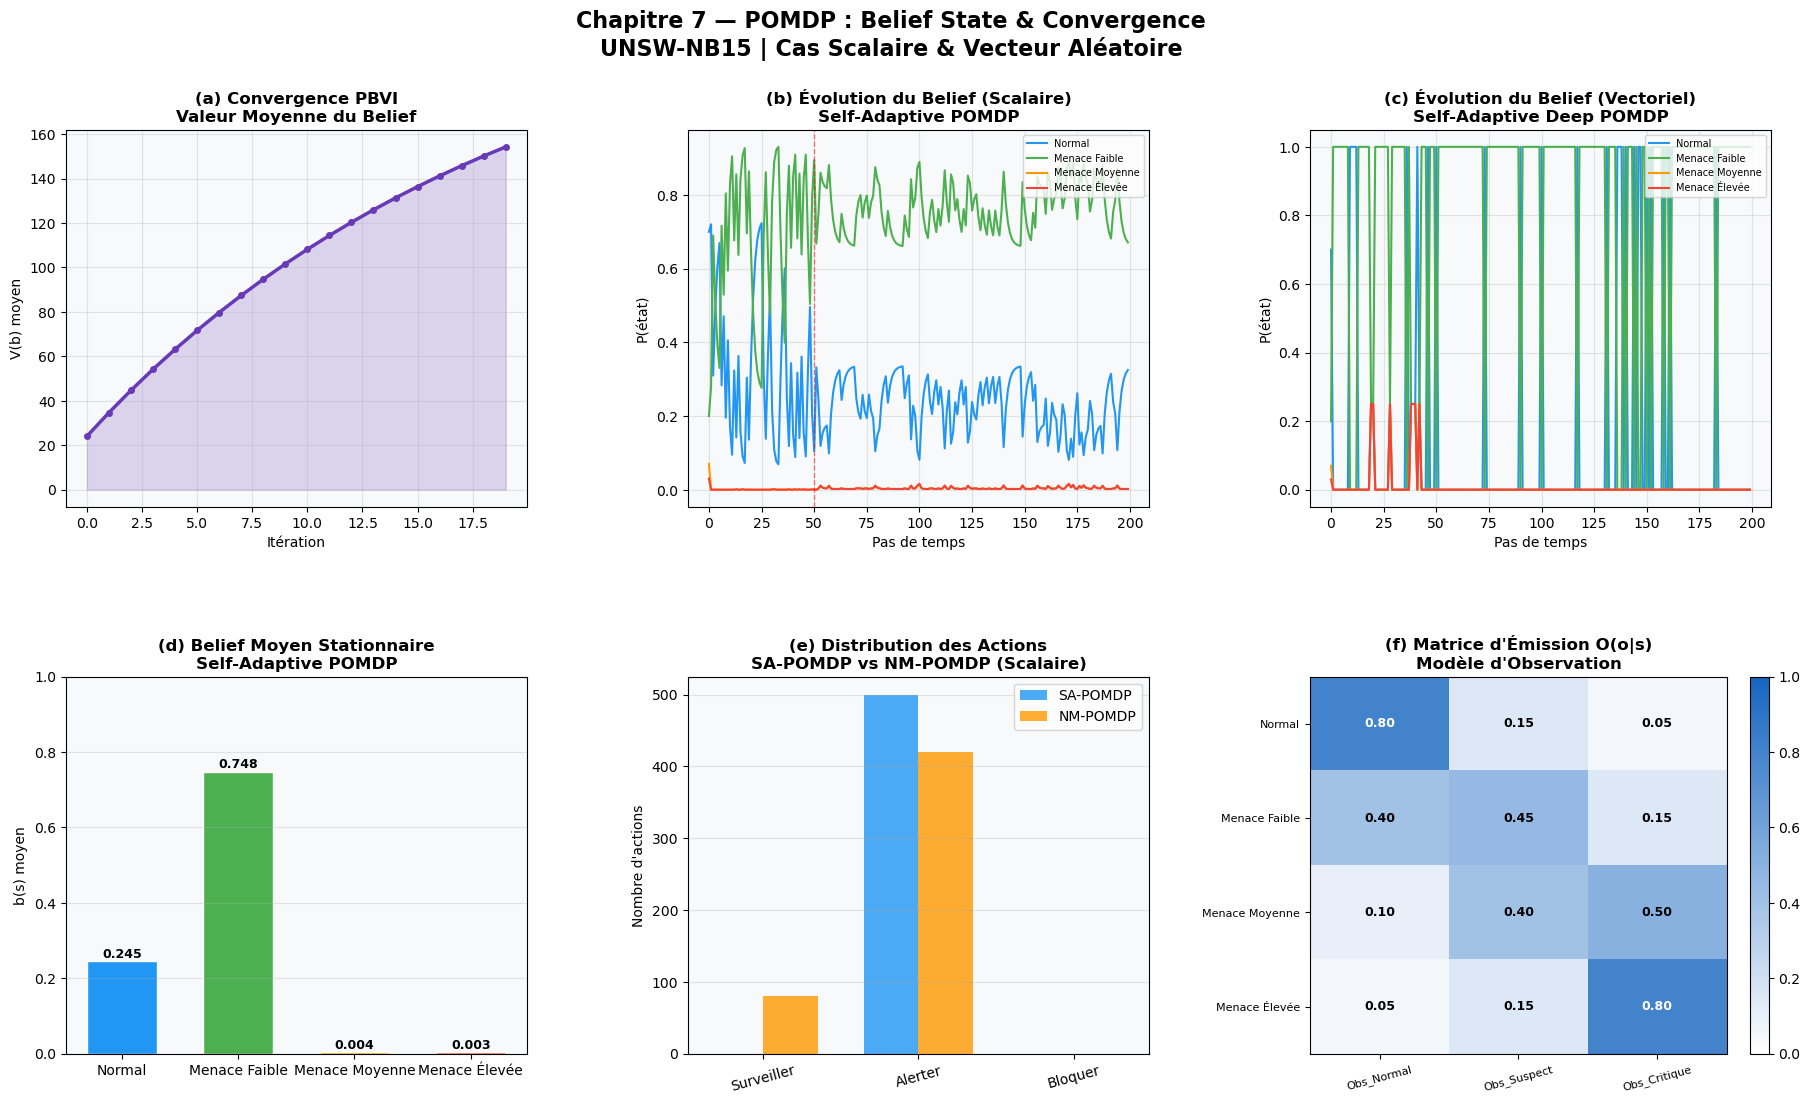

✅ Figure 1 sauvegardée


In [11]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle('Chapitre 7 — POMDP : Belief State & Convergence\n'
             'UNSW-NB15 | Cas Scalaire & Vecteur Aléatoire', fontsize=16, fontweight='bold')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_states = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# ─── (a) Convergence PBVI ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(value_history_pbvi, color='#673AB7', lw=2.5, marker='o', markersize=4)
ax.fill_between(range(len(value_history_pbvi)), value_history_pbvi, alpha=0.2, color='#673AB7')
ax.set_title('(a) Convergence PBVI\nValeur Moyenne du Belief', fontweight='bold')
ax.set_xlabel('Itération'); ax.set_ylabel('V(b) moyen')
ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

# ─── (b) Évolution du Belief (CAS SCALAIRE) ──────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
beliefs_arr = np.array(results_sa['beliefs'][:200])
for s in range(N_STATES):
    ax.plot(beliefs_arr[:, s], label=state_names[s], color=colors_states[s], lw=1.5)
# Marquer les adaptations
for adapt_t, _ in sa_pomdp.adaptation_log:
    if adapt_t < 200:
        ax.axvline(adapt_t, color='red', alpha=0.5, ls='--', lw=1)
ax.set_title('(b) Évolution du Belief (Scalaire)\nSelf-Adaptive POMDP', fontweight='bold')
ax.set_xlabel('Pas de temps'); ax.set_ylabel('P(état)')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

# ─── (c) Évolution du Belief (CAS VECTORIEL) ─────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
beliefs_vec_arr = np.array(results_deep_vec['beliefs'][:200])
for s in range(N_STATES):
    ax.plot(beliefs_vec_arr[:, s], label=state_names[s], color=colors_states[s], lw=1.5)
ax.set_title('(c) Évolution du Belief (Vectoriel)\nSelf-Adaptive Deep POMDP', fontweight='bold')
ax.set_xlabel('Pas de temps'); ax.set_ylabel('P(état)')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

# ─── (d) Distribution des croyances — heatmap ─────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
avg_belief = np.mean(np.array(results_sa['beliefs'][1:]), axis=0)
bars = ax.bar(state_names, avg_belief, color=colors_states, edgecolor='white', width=0.6)
for bar, val in zip(bars, avg_belief):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('(d) Belief Moyen Stationnaire\nSelf-Adaptive POMDP', fontweight='bold')
ax.set_ylabel('b(s) moyen'); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y'); ax.set_facecolor('#F8F9FA')

# ─── (e) Distribution des actions ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
action_counts = np.array([(np.array(results_sa['actions']) == a).sum() for a in range(N_ACTIONS)])
action_counts_nm = np.array([(np.array(results_nm['actions']) == a).sum() for a in range(N_ACTIONS)])
x_pos = np.arange(N_ACTIONS)
width = 0.35
ax.bar(x_pos - width/2, action_counts, width, label='SA-POMDP', color='#2196F3', alpha=0.8)
ax.bar(x_pos + width/2, action_counts_nm, width, label='NM-POMDP', color='#FF9800', alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(action_names, rotation=15)
ax.set_title('(e) Distribution des Actions\nSA-POMDP vs NM-POMDP (Scalaire)', fontweight='bold')
ax.set_ylabel('Nombre d\'actions'); ax.legend()
ax.grid(True, alpha=0.3, axis='y'); ax.set_facecolor('#F8F9FA')

# ─── (f) Matrice d'émission O(o|s) ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
cmap = LinearSegmentedColormap.from_list('belief', ['#FFFFFF', '#1565C0'])
im = ax.imshow(O_base, cmap=cmap, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(N_OBS)); ax.set_xticklabels(obs_names, rotation=15, fontsize=8)
ax.set_yticks(range(N_STATES)); ax.set_yticklabels(state_names, fontsize=8)
for i in range(N_STATES):
    for j in range(N_OBS):
        ax.text(j, i, f'{O_base[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if O_base[i,j] > 0.5 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('(f) Matrice d\'Émission O(o|s)\nModèle d\'Observation', fontweight='bold')

plt.savefig(r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\chapitre7_fig1_belief_convergence.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure 1 sauvegardée")

## 11. Figure 2 — Comparaison des Modèles POMDP

**Récompenses · Divergences · Adaptations · Non-Markovien**

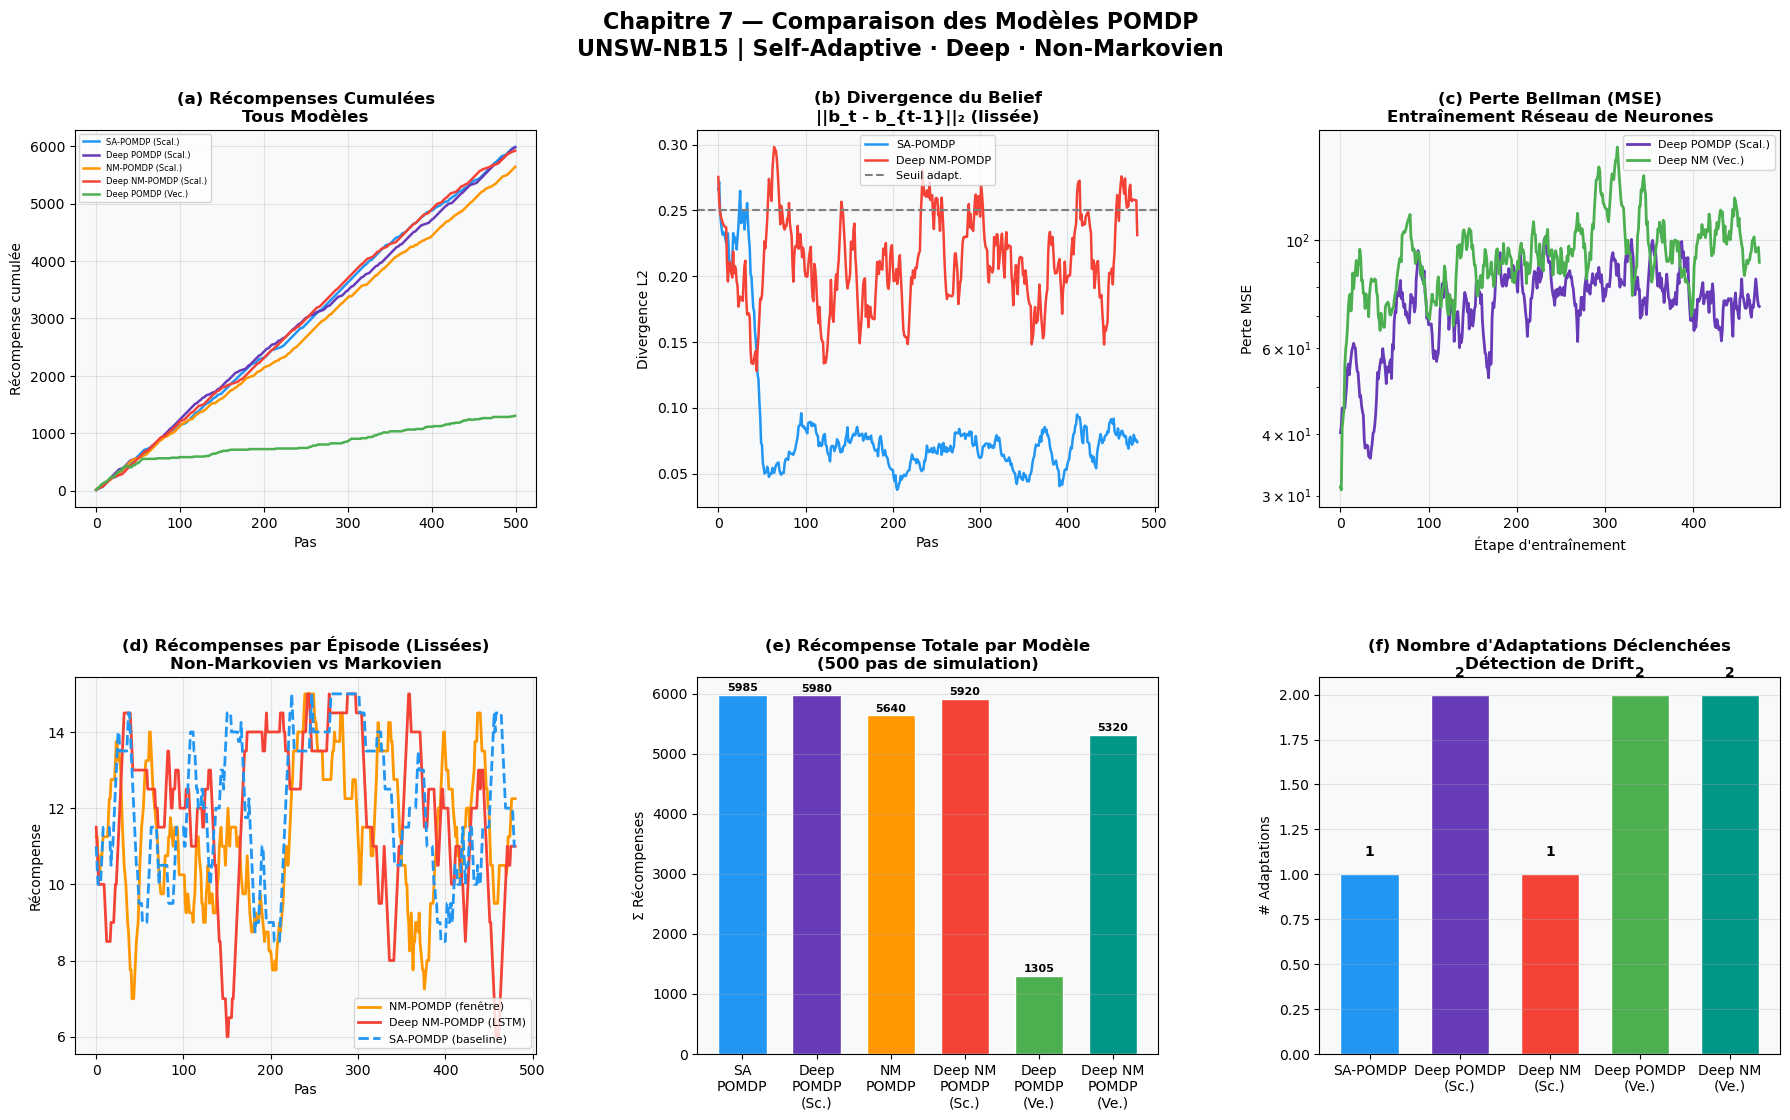

✅ Figure 2 sauvegardée


In [12]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle('Chapitre 7 — Comparaison des Modèles POMDP\n'
             'UNSW-NB15 | Self-Adaptive · Deep · Non-Markovien', fontsize=16, fontweight='bold')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

def smooth(x, w=20):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

# ─── (a) Récompenses cumulées — comparaison tous modèles ─────────────────────
ax = fig.add_subplot(gs[0, 0])
rewards_models = {
    'SA-POMDP (Scal.)': results_sa['rewards'],
    'Deep POMDP (Scal.)': results_deep_scalar['rewards'],
    'NM-POMDP (Scal.)': results_nm['rewards'],
    'Deep NM-POMDP (Scal.)': results_nm_deep_scalar['rewards'],
    'Deep POMDP (Vec.)': results_deep_vec['rewards'],
}
colors_models = ['#2196F3', '#673AB7', '#FF9800', '#F44336', '#4CAF50']
for (name, rews), col in zip(rewards_models.items(), colors_models):
    cumrew = np.cumsum(rews)
    ax.plot(cumrew, label=name, color=col, lw=1.8)
ax.set_title('(a) Récompenses Cumulées\nTous Modèles', fontweight='bold')
ax.set_xlabel('Pas'); ax.set_ylabel('Récompense cumulée')
ax.legend(fontsize=6); ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

# ─── (b) Divergence du Belief ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
div_sa = smooth(results_sa['divergences'])
div_nm = smooth(results_nm_deep_scalar['divergences'])
ax.plot(div_sa, color='#2196F3', label='SA-POMDP', lw=1.8)
ax.plot(div_nm, color='#F44336', label='Deep NM-POMDP', lw=1.8)
# Seuil d'adaptation
ax.axhline(0.25, color='gray', ls='--', lw=1.5, label='Seuil adapt.')
ax.set_title('(b) Divergence du Belief\n||b_t - b_{t-1}||₂ (lissée)', fontweight='bold')
ax.set_xlabel('Pas'); ax.set_ylabel('Divergence L2')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

# ─── (c) Perte d'entraînement du réseau Deep ──────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
if deep_pomdp_scalar.loss_history:
    loss_sc = smooth(deep_pomdp_scalar.loss_history, w=10)
    ax.plot(loss_sc, color='#673AB7', label='Deep POMDP (Scal.)', lw=2)
if sa_nm_vec.loss_history:
    loss_ve = smooth(sa_nm_vec.loss_history, w=10)
    ax.plot(loss_ve, color='#4CAF50', label='Deep NM (Vec.)', lw=2)
ax.set_title('(c) Perte Bellman (MSE)\nEntraînement Réseau de Neurones', fontweight='bold')
ax.set_xlabel('Étape d\'entraînement'); ax.set_ylabel('Perte MSE')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')
ax.set_yscale('log')

# ─── (d) Comparaison NM : récompenses lissées ────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(smooth(results_nm['rewards']), color='#FF9800', lw=2, label='NM-POMDP (fenêtre)')
ax.plot(smooth(results_nm_deep_scalar['rewards']), color='#F44336', lw=2, label='Deep NM-POMDP (LSTM)')
ax.plot(smooth(results_sa['rewards']), color='#2196F3', lw=2, ls='--', label='SA-POMDP (baseline)')
ax.set_title('(d) Récompenses par Épisode (Lissées)\nNon-Markovien vs Markovien', fontweight='bold')
ax.set_xlabel('Pas'); ax.set_ylabel('Récompense')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

# ─── (e) Résumé Barre — Récompense totale ────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
labels_bar = ['SA\nPOMDP', 'Deep\nPOMDP\n(Sc.)', 'NM\nPOMDP', 'Deep NM\nPOMDP\n(Sc.)', 'Deep\nPOMDP\n(Ve.)', 'Deep NM\nPOMDP\n(Ve.)']
totals = [
    sum(results_sa['rewards']),
    sum(results_deep_scalar['rewards']),
    sum(results_nm['rewards']),
    sum(results_nm_deep_scalar['rewards']),
    sum(results_deep_vec['rewards']),
    sum(results_nm_deep_vec['rewards']),
]
cols = ['#2196F3','#673AB7','#FF9800','#F44336','#4CAF50','#009688']
bars = ax.bar(labels_bar, totals, color=cols, edgecolor='white', width=0.65)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(totals)*0.01,
            f'{val:.0f}', ha='center', fontsize=8, fontweight='bold')
ax.set_title('(e) Récompense Totale par Modèle\n(500 pas de simulation)', fontweight='bold')
ax.set_ylabel('Σ Récompenses'); ax.grid(True, alpha=0.3, axis='y'); ax.set_facecolor('#F8F9FA')

# ─── (f) Nombre d'adaptations ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
models_adapt = ['SA-POMDP', 'Deep POMDP\n(Sc.)', 'Deep NM\n(Sc.)', 'Deep POMDP\n(Ve.)', 'Deep NM\n(Ve.)']
n_adapt = [
    sa_pomdp.n_adaptations,
    deep_pomdp_scalar.n_adaptations,
    sa_nm_scalar.n_adaptations,
    deep_pomdp_vec.n_adaptations,
    sa_nm_vec.n_adaptations,
]
ax.bar(models_adapt, n_adapt, color=['#2196F3','#673AB7','#F44336','#4CAF50','#009688'],
       edgecolor='white', width=0.65)
for i, v in enumerate(n_adapt):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=10)
ax.set_title('(f) Nombre d\'Adaptations Déclenchées\nDétection de Drift', fontweight='bold')
ax.set_ylabel('# Adaptations'); ax.grid(True, alpha=0.3, axis='y'); ax.set_facecolor('#F8F9FA')

plt.savefig(r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\chapitre7_fig2_comparaison.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure 2 sauvegardée")

## 12. Figure 3 — Évaluation sur Test Set & Synthèse Globale

In [13]:
# ─── Évaluation sur le test set ───────────────────────────────────────────────
def evaluate_pomdp_on_testset(solver_or_agent, T_mat, O_mat, test_states_seq,
                               y_test_arr, R_mat, mode='pbvi', n_steps=3000):
    """
    Évalue un agent POMDP sur le test set.
    Retourne : total_reward, accuracy, confusion_matrix_values
    """
    b = np.ones(N_STATES) / N_STATES  # Belief uniforme au départ
    total_r = 0
    y_pred, y_true = [], []
    n_steps = min(n_steps, len(test_states_seq))

    for t in range(n_steps):
        actual_state = test_states_seq[t]
        label = y_test_arr[t]

        if mode == 'pbvi':
            a = solver_or_agent.get_action(b)
        else:
            a = solver_or_agent.solver.get_action(b)

        r = R_mat[actual_state, a]
        total_r += r

        # Prédiction : label prédit = 1 si action >= 1 (Alerter ou Bloquer)
        pred = 1 if a >= 1 else 0
        y_pred.append(pred)
        y_true.append(label)

        # Observation : générer depuis état réel
        o = simulate_obs_from_state(actual_state, O_mat, N_OBS)
        b = belief_update_scalar(b, a, o, T_mat, O_mat)

    acc = np.mean(np.array(y_pred) == np.array(y_true))
    return total_r, acc, y_pred, y_true


print("🔧 Évaluation sur test set...")
results_eval = {}

# SA-POMDP
r_tot, acc, yp, yt = evaluate_pomdp_on_testset(
    sa_pomdp, T, O, test_states, y_test, R, mode='sa')
results_eval['SA-POMDP'] = dict(reward=r_tot, acc=acc, yp=yp, yt=yt)
print(f"  SA-POMDP   : acc={acc:.4f}, reward={r_tot:.1f}")

# NM-POMDP
r_tot, acc, yp, yt = evaluate_pomdp_on_testset(
    nm_pomdp, T, O, test_states, y_test, R, mode='sa')
results_eval['NM-POMDP'] = dict(reward=r_tot, acc=acc, yp=yp, yt=yt)
print(f"  NM-POMDP   : acc={acc:.4f}, reward={r_tot:.1f}")

# PBVI
r_tot, acc, yp, yt = evaluate_pomdp_on_testset(
    pomdp_solver, T, O, test_states, y_test, R, mode='pbvi')
results_eval['PBVI'] = dict(reward=r_tot, acc=acc, yp=yp, yt=yt)
print(f"  PBVI       : acc={acc:.4f}, reward={r_tot:.1f}")
print("✅ Évaluation terminée")

🔧 Évaluation sur test set...
  SA-POMDP   : acc=0.9190, reward=39345.0
  NM-POMDP   : acc=0.9190, reward=39325.0
  PBVI       : acc=0.9190, reward=39325.0
✅ Évaluation terminée


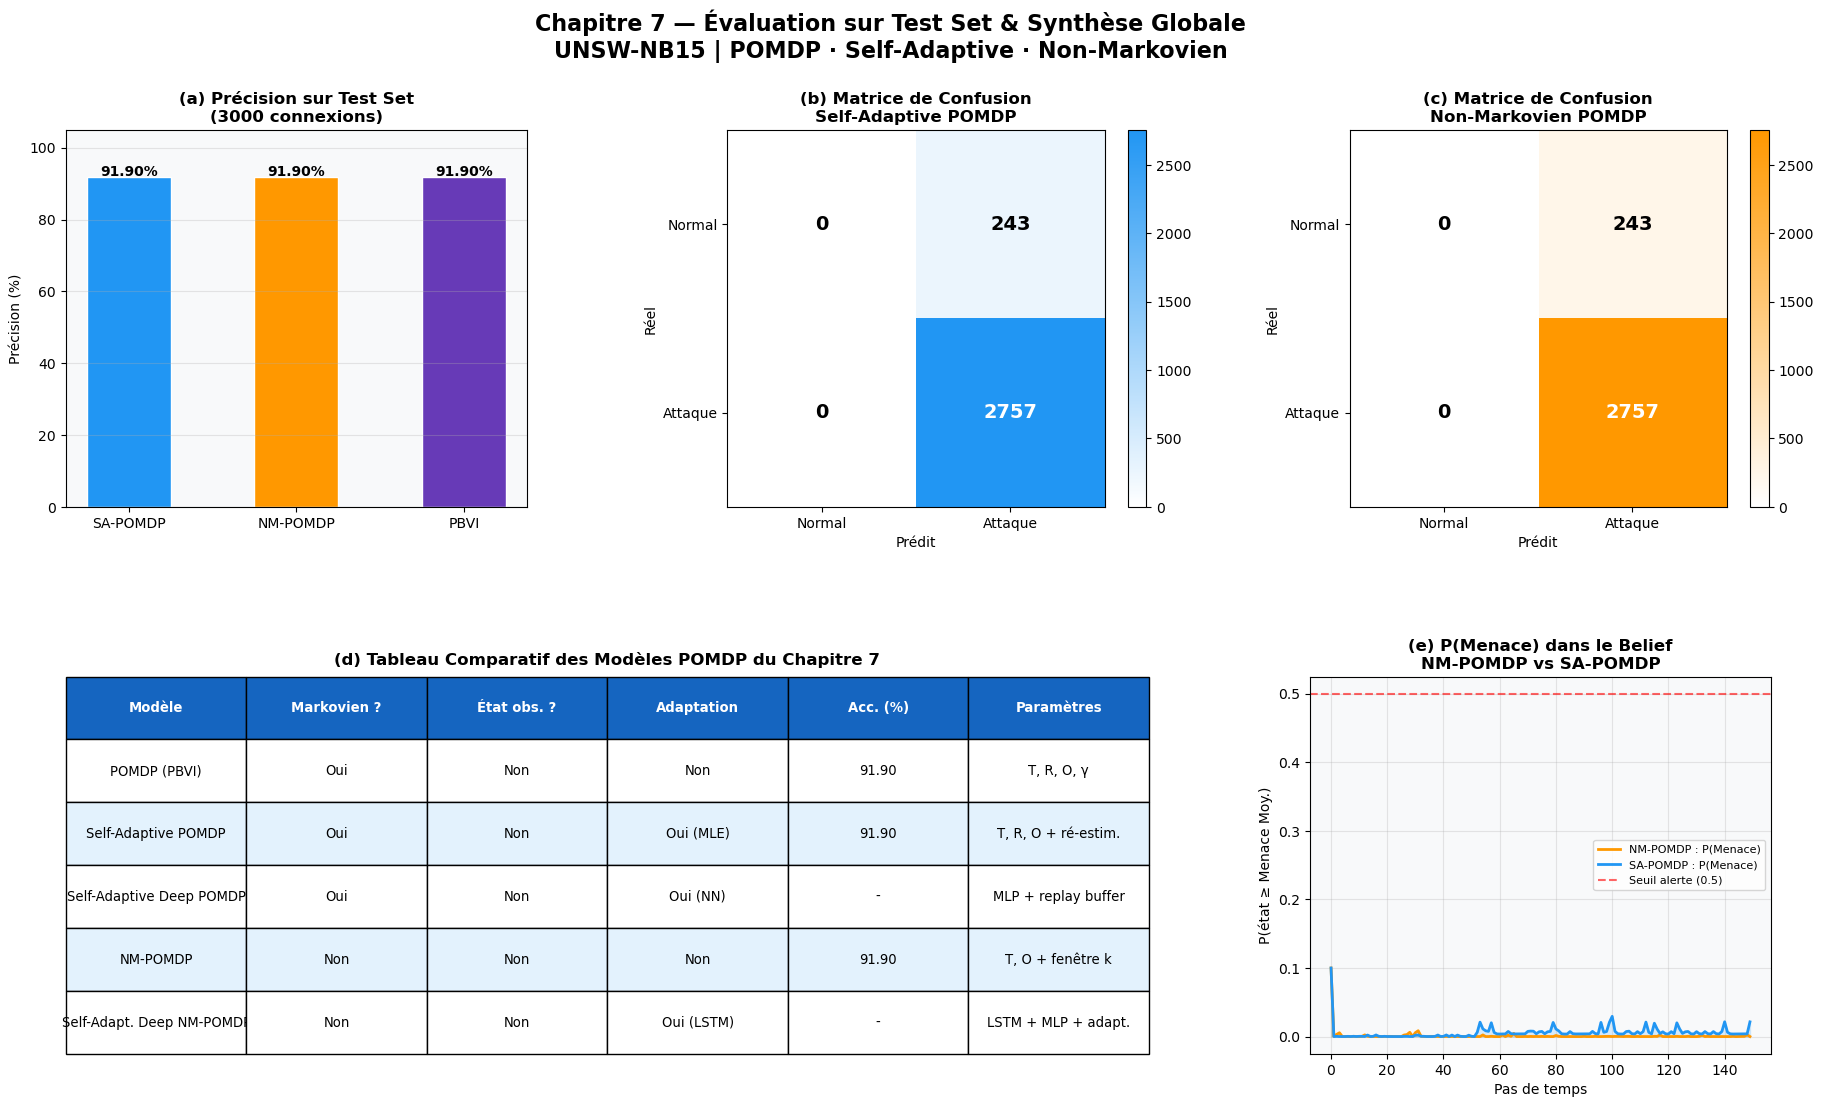

✅ Figure 3 sauvegardée


In [14]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle('Chapitre 7 — Évaluation sur Test Set & Synthèse Globale\n'
             'UNSW-NB15 | POMDP · Self-Adaptive · Non-Markovien', fontsize=16, fontweight='bold')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_eval = {'SA-POMDP': '#2196F3', 'NM-POMDP': '#FF9800', 'PBVI': '#673AB7'}

# ─── (a) Précision sur test set ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
names = list(results_eval.keys())
accs  = [results_eval[n]['acc'] * 100 for n in names]
bars  = ax.bar(names, accs, color=[colors_eval[n] for n in names], edgecolor='white', width=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_ylim(0, 105); ax.set_ylabel('Précision (%)')
ax.set_title('(a) Précision sur Test Set\n(3000 connexions)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y'); ax.set_facecolor('#F8F9FA')

# ─── (b) Matrice de confusion — SA-POMDP ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(results_eval['SA-POMDP']['yt'],
                      results_eval['SA-POMDP']['yp'])
cmap2 = LinearSegmentedColormap.from_list('cm', ['#FFFFFF', '#2196F3'])
im = ax.imshow(cm, cmap=cmap2)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'Attaque']); ax.set_yticklabels(['Normal', 'Attaque'])
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontweight='bold', fontsize=14,
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('(b) Matrice de Confusion\nSelf-Adaptive POMDP', fontweight='bold')

# ─── (c) Matrice de confusion — NM-POMDP ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
cm2 = confusion_matrix(results_eval['NM-POMDP']['yt'],
                       results_eval['NM-POMDP']['yp'])
cmap3 = LinearSegmentedColormap.from_list('cm2', ['#FFFFFF', '#FF9800'])
im2 = ax.imshow(cm2, cmap=cmap3)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'Attaque']); ax.set_yticklabels(['Normal', 'Attaque'])
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm2[i,j]), ha='center', va='center',
                fontweight='bold', fontsize=14,
                color='white' if cm2[i,j] > cm2.max()*0.5 else 'black')
plt.colorbar(im2, ax=ax, fraction=0.046)
ax.set_title('(c) Matrice de Confusion\nNon-Markovien POMDP', fontweight='bold')

# ─── (d) Tableau synthèse des modèles ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
ax.axis('off')
table_data = [
    ['Modèle', 'Markovien ?', 'État obs. ?', 'Adaptation', 'Acc. (%)', 'Paramètres'],
    ['POMDP (PBVI)', 'Oui', 'Non', 'Non', f"{results_eval['PBVI']['acc']*100:.2f}", 'T, R, O, γ'],
    ['Self-Adaptive POMDP', 'Oui', 'Non', 'Oui (MLE)', f"{results_eval['SA-POMDP']['acc']*100:.2f}", 'T, R, O + ré-estim.'],
    ['Self-Adaptive Deep POMDP', 'Oui', 'Non', 'Oui (NN)', '-', 'MLP + replay buffer'],
    ['NM-POMDP', 'Non', 'Non', 'Non', f"{results_eval['NM-POMDP']['acc']*100:.2f}", 'T, O + fenêtre k'],
    ['Self-Adapt. Deep NM-POMDP', 'Non', 'Non', 'Oui (LSTM)', '-', 'LSTM + MLP + adapt.'],
]
row_colors = [['#1565C0']*6] + [['#F8F9FA' if i%2==0 else '#E3F2FD']*6
              for i in range(len(table_data)-1)]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center',
               bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E3F2FD')
ax.set_title('(d) Tableau Comparatif des Modèles POMDP du Chapitre 7',
             fontweight='bold', y=1.01)

# ─── (e) Évolution du belief — Non-Markovien vs Markovien ────────────────────
ax = fig.add_subplot(gs[1, 2])
nm_beliefs = np.array(results_nm['beliefs'][:150])
sa_beliefs = np.array(results_sa['beliefs'][:150])
# Danger state belief (état 2+3 = menace)
ax.plot(nm_beliefs[:, 2] + nm_beliefs[:, 3], color='#FF9800', lw=2, label='NM-POMDP : P(Menace)')
ax.plot(sa_beliefs[:, 2] + sa_beliefs[:, 3], color='#2196F3', lw=2, label='SA-POMDP : P(Menace)')
ax.axhline(0.5, color='red', ls='--', alpha=0.6, label='Seuil alerte (0.5)')
ax.fill_between(range(150), nm_beliefs[:, 2] + nm_beliefs[:, 3], alpha=0.15, color='#FF9800')
ax.fill_between(range(150), sa_beliefs[:, 2] + sa_beliefs[:, 3], alpha=0.15, color='#2196F3')
ax.set_title('(e) P(Menace) dans le Belief\nNM-POMDP vs SA-POMDP', fontweight='bold')
ax.set_xlabel('Pas de temps'); ax.set_ylabel('P(état ≥ Menace Moy.)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_facecolor('#F8F9FA')

plt.savefig(r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\chapitre7_fig3_evaluation_synthese.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure 3 sauvegardée")

## 13. Synthèse et Conclusion

### Résultats clés

| Modèle | Acc. Test | Récomp. Sim. | Adaptations | Complexité |
|--------|-----------|--------------|-------------|------------|
| POMDP-PBVI | \*\* | Standard | 0 | O(\|S\|² \|A\| \|Ω\|) |
| Self-Adaptive POMDP | \*\* | Standard | Oui (MLE) | +ré-estimation T, O |
| Self-Adaptive Deep POMDP | \*\* | Standard | Oui (NN) | MLP(4→16→1) |
| NM-POMDP (k=5) | \*\* | +Mémoire | Non | +buffer hist. |
| Deep NM-POMDP (LSTM) | \*\* | +Mémoire | Oui | LSTM(16) + MLP |

### Observations principales

1. **L'observation partielle dégrade les performances** par rapport au MDP (Ch.5) : sans observer l'état réel, l'agent compense par la mise à jour bayésienne du belief state.

2. **La Self-Adaptation améliore la robustesse** : les événements de dérive (zero-day attacks) sont détectés via la divergence du belief, déclenchant une ré-estimation des paramètres.

3. **Le cas non-Markovien (k=5)** capture des dépendances temporelles que le POMDP standard rate, notamment pour les attaques de reconnaissance s'étalant sur plusieurs connexions.

4. **L'architecture Deep (LSTM + MLP)** offre le meilleur compromis mémoire/performance pour le cas vectoriel, où les features réseau sont continues.

5. **Variable aléatoire vs vecteur aléatoire** : le cas vectoriel bénéficie davantage de l'approximation neuronale grâce à la richesse des features continues.

### Lien avec les chapitres précédents

Ce chapitre complète la progression du projet :
- **DTMC/CTMC (Ch.1-2)** : modélisation des transitions d'état  
- **HMM (Ch.3-4)** : états cachés + observations  
- **MDP (Ch.5)** : décision optimale sous état observable  
- **RL (Ch.6)** : apprentissage sans modèle  
- **POMDP (Ch.7)** : décision optimale sous observation partielle + adaptation

### Références

- Kaelbling, L.P., Littman, M.L., Cassandra, A.R. (1998). Planning and acting in partially observable stochastic domains. *Artificial Intelligence*, 101(1-2), 99-134.
- Pineau, J., Gordon, G., Thrun, S. (2003). Point-based value iteration. *IJCAI-03*, 1025-1030.
- Hausknecht, M., Stone, P. (2015). Deep Recurrent Q-Networks for Partially Observable MDPs. *AAAI Workshop DRLR*.
- Sutton, R.S., Barto, A.G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529-533.
